In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc
from scanpy import AnnData
sc.set_figure_params(figsize=(4,4))
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype']=42
# plt.rcParams['font.sans-serif'] = 'Arial'
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scanpy import AnnData

In [2]:
meta=pd.read_csv('../metadata_passQC_05212026.tsv.gz',sep='\t').set_index('ID')
meta.head(1)

,L1,L2,L3,L4,age,age_groups,region,mCG/CG_global,mCH/CH_global,mCCC/CCC_global,...,pairs_enzymeless_intra20kb,pairs_enzymeless_inter,pairs_dup_rate,high_coverage_pairs,allc_input_genome_coverage_dup,allc_input_genome_coverage_dedup,allc_input_mapped_bp_dup,allc_input_mapped_bp_dedup,mCG/CG_chrL,mCH/CH_chrL
ID,,,,,,,,,,,,,,,,,,,,,
20210111-1863-preAb-PFC-B12_A1,Exc,UL,L1-3-CUX2,L1-3-CUX2,31,adult,DFC,0.77233,0.059992,0.012849,...,4499.0,1399.0,0.377175,81.0,44221255.0,44221255.0,45085203.0,45085203.0,NaN,NaN


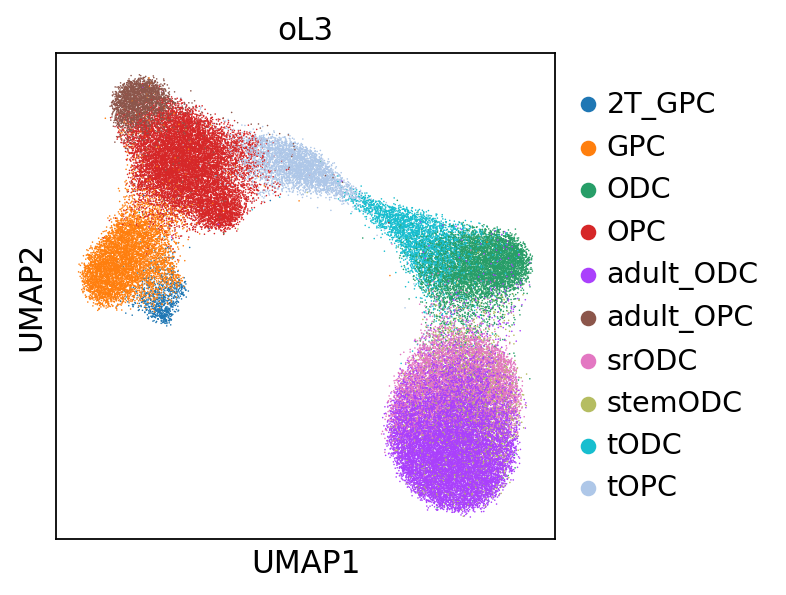

In [3]:
adata=sc.read_h5ad('../OPDC/OPDC_3CGS_smoothed_scaled_04072026.h5ad')
sc.pl.umap(adata,color='oL3')

In [4]:
for c in meta.columns:
    if c=='oL3':
        adata.obs['oL3-2']=meta['oL3']
    else:
        adata.obs[c]=meta[c]

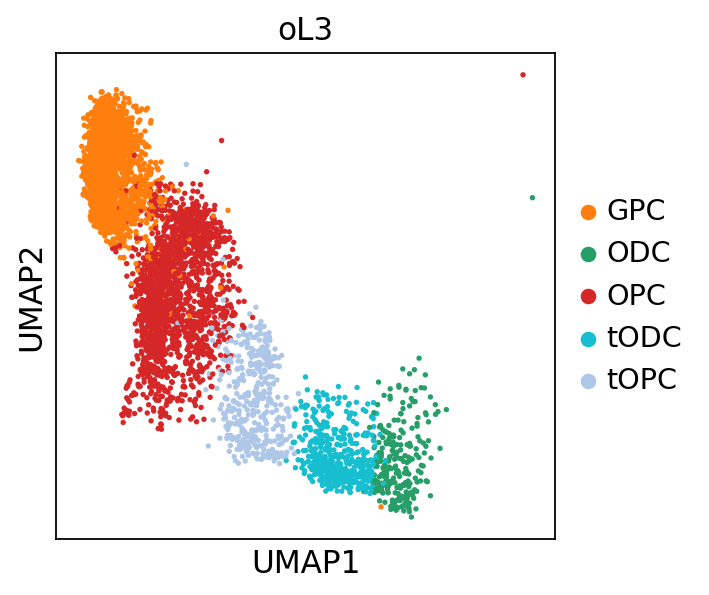

In [5]:
#3T to match COSMX sample age
adata=adata[adata.obs['age_groups'].isin(['3T'])]
adata=adata[adata.obs['oL3'].isin(['GPC','OPC','tOPC','tODC','ODC'])]
sc.pl.umap(adata,color='oL3')

In [6]:
adata2=sc.read_h5ad('/u/project/cluo/rayirfan/cosmx/analyses/basalganglia/E_returned/gw35oligo_ish_cells.h5ad')

In [7]:
adata.var_names_make_unique()

In [8]:
cdata=adata
cdata=adata[:,adata.var[adata.var['highly_variable']==True].index].copy()

In [9]:
cdata=cdata.concatenate(adata2)

In [10]:
sc.tl.pca(cdata)

In [11]:
sc.external.pp.harmony_integrate(cdata, 'batch',max_iter_harmony=20)
sc.pp.neighbors(cdata,n_pcs=20,n_neighbors=20,use_rep='X_pca_harmony')

2026-06-05 11:55:29,328 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-05 11:55:38,311 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-05 11:55:38,561 - harmonypy - INFO - Iteration 1 of 20
2026-06-05 11:55:53,840 - harmonypy - INFO - Iteration 2 of 20
2026-06-05 11:56:09,181 - harmonypy - INFO - Iteration 3 of 20
2026-06-05 11:56:26,614 - harmonypy - INFO - Iteration 4 of 20
2026-06-05 11:56:43,055 - harmonypy - INFO - Iteration 5 of 20
2026-06-05 11:56:59,277 - harmonypy - INFO - Iteration 6 of 20
2026-06-05 11:57:15,171 - harmonypy - INFO - Iteration 7 of 20
2026-06-05 11:57:33,006 - harmonypy - INFO - Iteration 8 of 20
2026-06-05 11:57:49,865 - harmonypy - INFO - Iteration 9 of 20
2026-06-05 11:58:07,531 - harmonypy - INFO - Converged after 9 iterations


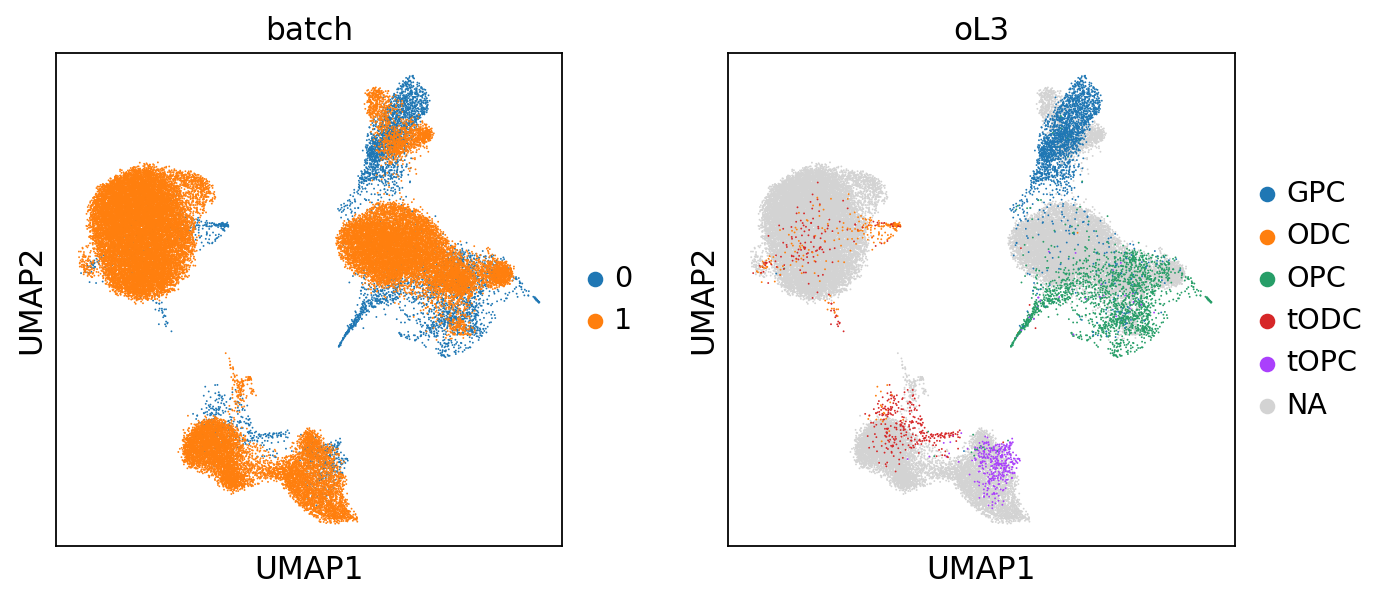

In [12]:
sc.tl.umap(cdata)
sc.tl.leiden(cdata)
sc.pl.umap(cdata,color=['batch','oL3'])

In [13]:
sc.external.pp.bbknn(cdata, batch_key="batch",use_rep='X_pca_harmony') 

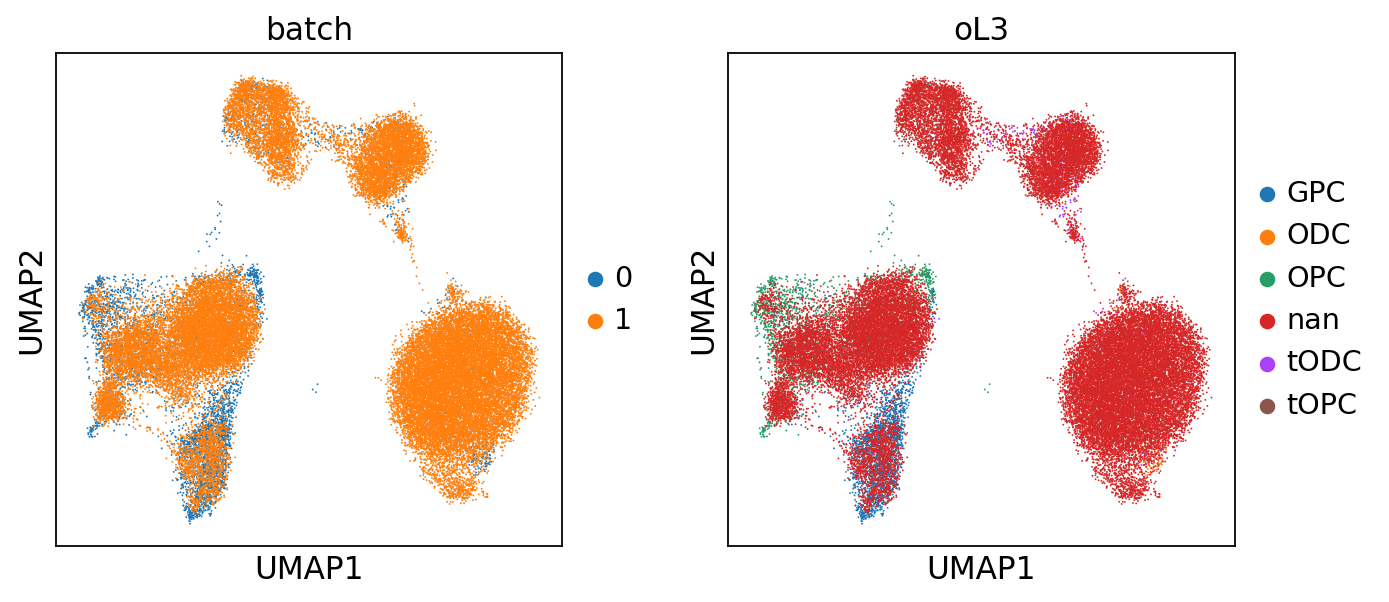

In [14]:
sc.tl.umap(cdata)
sc.tl.leiden(cdata)
cdata=sc.read_h5ad('integrated_cosmx-3cgs_bgs5.h5ad')
sc.pl.umap(cdata,color=['batch','oL3'])

In [15]:
cdata.obs=cdata.obs[['oL3','batch','age_groups','age','mCG/CG_global','mCH/CH_global','region']]

In [16]:
for c in cdata.obs.columns:
    cdata.obs[c]=cdata.obs[c].astype(str)

In [17]:
# cdata.write_h5ad('integrated_cosmx-3cgs_bgs5.h5ad')

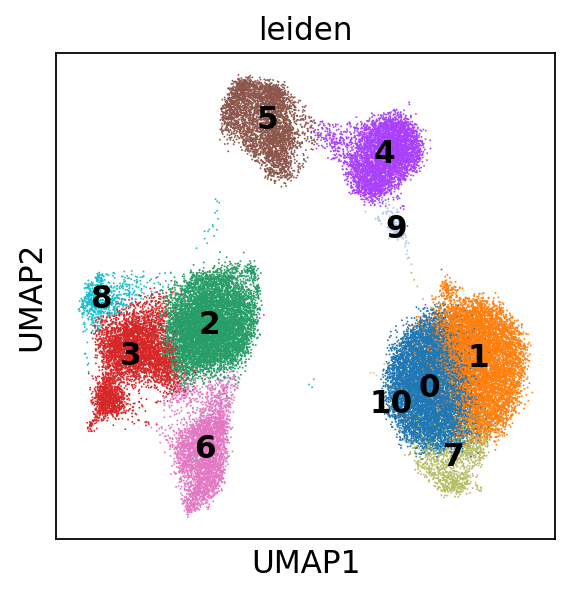

In [18]:
sc.tl.leiden(cdata)
sc.pl.umap(cdata,color='leiden',legend_loc='on data')

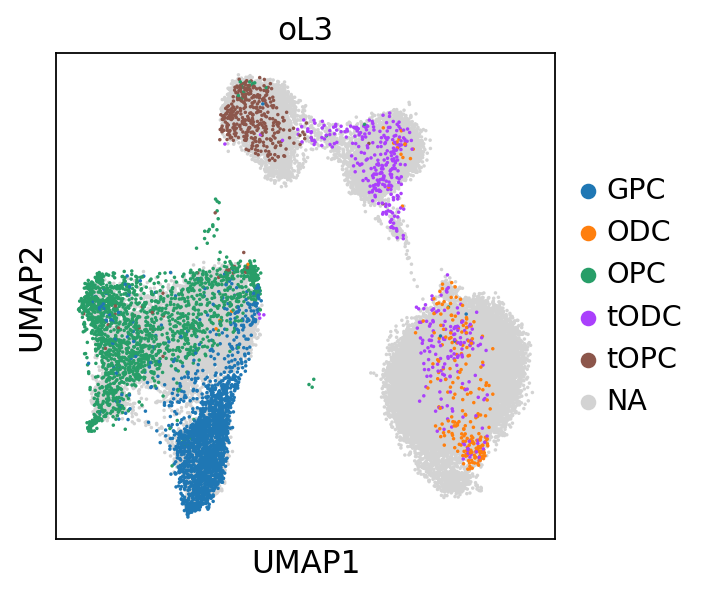

In [19]:
sc.pl.umap(cdata,color='oL3',size=10,groups=['GPC','OPC','tOPC','tODC','ODC'])

In [20]:
cosdata=cdata[cdata.obs['batch']=='1']

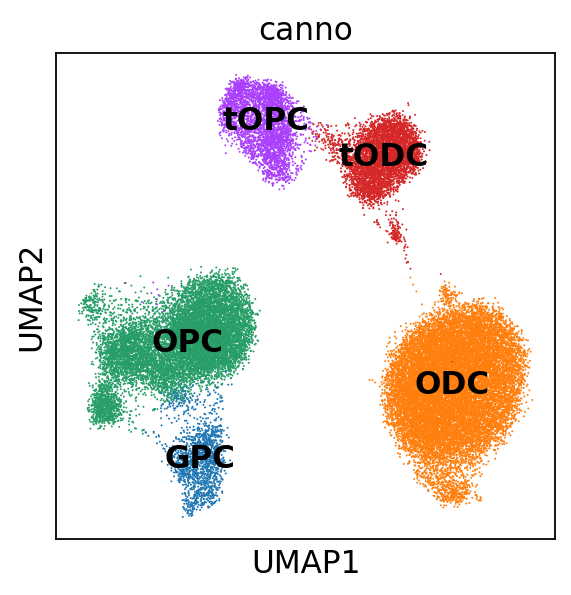

In [21]:
clust_map={}
clust_map['0']='ODC'
clust_map['1']='ODC'
clust_map['2']='OPC'
clust_map['3']='OPC'
clust_map['4']='tODC'
clust_map['5']='tOPC'
clust_map['6']='GPC'
clust_map['7']='ODC'
clust_map['8']='OPC'
clust_map['9']='tODC'
clust_map['10']='ODC'
#obs rewrite based on other columns 
cosdata.obs['canno']=''
cosdata.obs['temp_clust']=cosdata.obs['leiden'].apply(lambda i: clust_map[i] if i in clust_map else np.nan)
cosdata.obs['canno']=np.where(cosdata.obs['temp_clust'].isnull(),cosdata.obs['canno'],cosdata.obs['temp_clust'])
sc.pl.umap(cosdata,color='canno',legend_loc='on data')

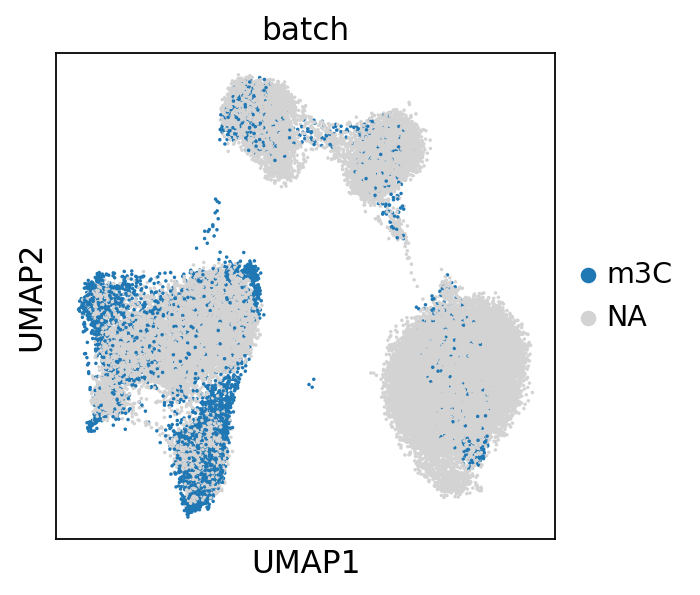

In [22]:
rng = np.random.default_rng(0)
cdata_shuf = cdata[rng.permutation(cdata.n_obs)].copy()
cdata_shuf.obs['batch']=cdata_shuf.obs['batch'].replace('0','m3C')
cdata_shuf.obs['batch']=cdata_shuf.obs['batch'].replace('1','cosmx')
sc.pl.umap(cdata_shuf, color="batch", sort_order=False,save='int_batch.pdf',groups=['m3C'],size=10)

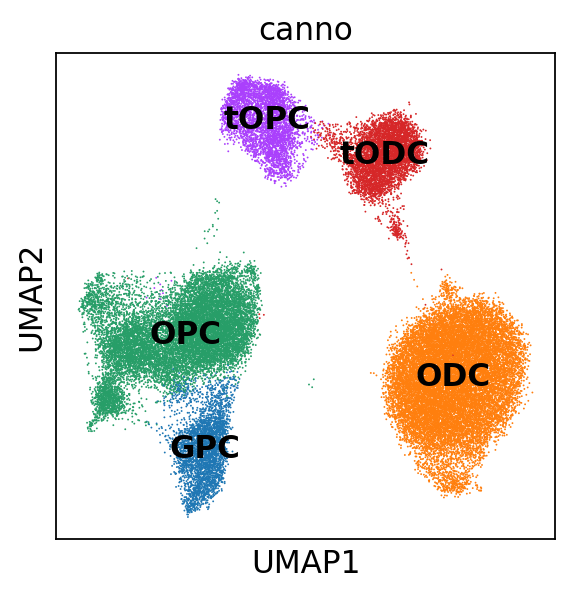

In [23]:
clust_map={}
clust_map['0']='ODC'
clust_map['1']='ODC'
clust_map['2']='OPC'
clust_map['3']='OPC'
clust_map['4']='tODC'
clust_map['5']='tOPC'
clust_map['6']='GPC'
clust_map['7']='ODC'
clust_map['8']='OPC'
clust_map['9']='tODC'
clust_map['10']='ODC'

cdata.obs['canno']=''
cdata.obs['temp_clust']=cdata.obs['leiden'].apply(lambda i: clust_map[i] if i in clust_map else np.nan)
cdata.obs['canno']=np.where(cdata.obs['temp_clust'].isnull(),cdata.obs['canno'],cdata.obs['temp_clust'])
sc.pl.umap(cdata,color='canno',legend_loc='on data')

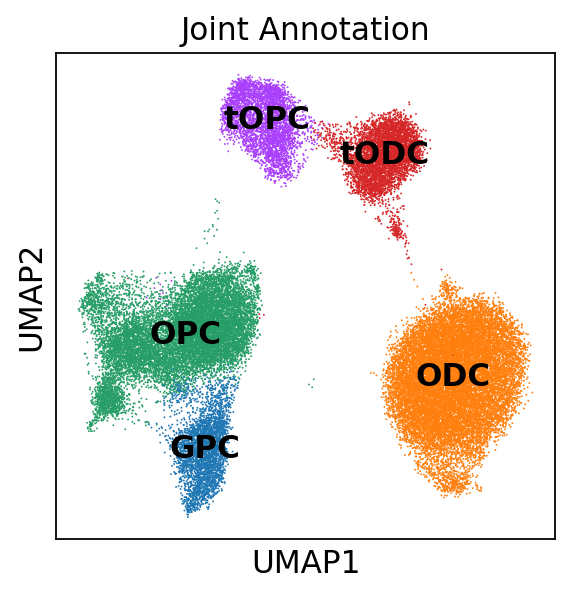

In [24]:
cdata.obs['Joint Annotation']=cdata.obs['canno']
sc.pl.umap(cdata,color='Joint Annotation',legend_loc='on data',save='int_anno.pdf')

In [25]:
#restore cosdata to full gene set, not just 3CGS intersect
cosdata.obs.index=[i[:-2] for i in cosdata.obs.index]
cosanno=cosdata.obs
cosdata=sc.read_h5ad('/u/project/cluo/rayirfan/cosmx/analyses/basalganglia/E_returned/gw35oligo_ish_cells.h5ad')
cosdata.obs['canno']=cosanno['canno']

In [26]:
cosdata=cosdata[cosdata.obs['canno']!='GPC']
sc.tl.rank_genes_groups(cosdata,groupby='canno')
order=['OPC','tOPC','tODC','ODC']
celltype_genes={}
for ct in order:
    tdf=sc.get.rank_genes_groups_df(cosdata,ct)
    tdf=tdf[tdf['pvals_adj']<.05]
    tdf=tdf[tdf['logfoldchanges']>=.1]
    tdf=tdf[tdf['scores']>5] #.head(50)
    celltype_genes[ct]=list(tdf['names'])
    print(len(celltype_genes[ct]))

34
334
14
1473


In [27]:
import gseapy as gp
import pandas as pd
import json

def run_go_enrichment(celltype_genes):
    with open('/u/project/cluo/heffel/BICAN3/REVISION/GO_DBs/GO_Biological_Process_2025.json', 'r') as f:
        gene_sets = json.load(f)

    results = {}
    for celltype, genes in celltype_genes.items():
        print(celltype)
        enr = gp.enrich(
            gene_list=genes,
            gene_sets=gene_sets,
            outdir=None,
            cutoff=0.05,
            background=None,
        )
        if enr is not None and not enr.results.empty:
            df = enr.results.copy()
            df['celltype'] = celltype
            results[celltype] = df

    all_results = pd.concat(results.values(), ignore_index=True)
    sig = all_results[all_results['Adjusted P-value'] <= 0.1].copy()
    sig['GeneRatio'] = sig['Overlap'].apply(lambda x: int(x.split('/')[0]) / int(x.split('/')[1]))
    top_n = (
        sig.sort_values('Adjusted P-value')
           .groupby('celltype')
           .head(50)
    )
    return top_n



from matplotlib.colors import LinearSegmentedColormap
def plot_go_enrichment(top_n):
    reds_clipped = LinearSegmentedColormap.from_list(
        'Reds_clipped', plt.cm.Reds(np.linspace(0.2, 1.0, 256))
    )
    figsize_map = {'ODC': (11, 4), 'OPC': (11, 4), 'tODC': (14, 4), 'tOPC': (11, 4)}

    for ct, df in top_n.groupby('celltype'):
        print(ct)
        df_plot = df.nsmallest(10, 'Adjusted P-value')
        df_plot['Term'] = df_plot['Term'].str.split(r' \(GO').str[0]
        df_plot = df_plot.sort_values('Adjusted P-value', ascending=False)

        figsize = figsize_map.get(ct, (12, 4))
        fig, ax = plt.subplots(figsize=figsize)

        log_pval = -np.log10(df_plot['Adjusted P-value'])
        combined = df_plot['Combined Score']
        norm = plt.Normalize(vmin=0, vmax=combined.max())
        colors = reds_clipped(norm(combined))

        ax.barh(df_plot['Term'], log_pval, color=colors)

        sm = plt.cm.ScalarMappable(cmap=reds_clipped, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Combined Score')

        ax.tick_params(axis='y', labelsize=18)
        ax.set_xlabel('-log10(Adjusted P-value)')
        ax.set_title(f'GO BP enrichment — {ct}')
        plt.tight_layout()
        plt.show()


OPC
tOPC
tODC
ODC
ODC


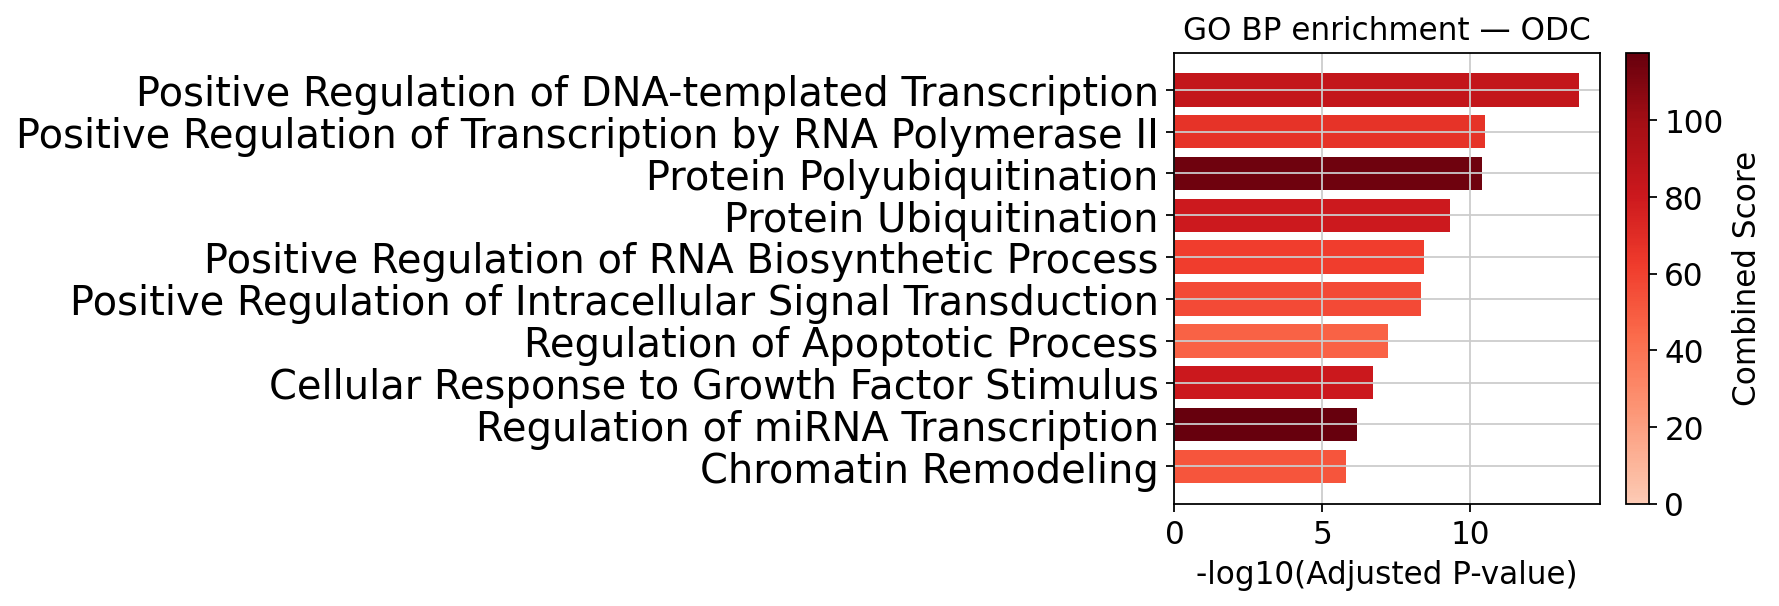

OPC


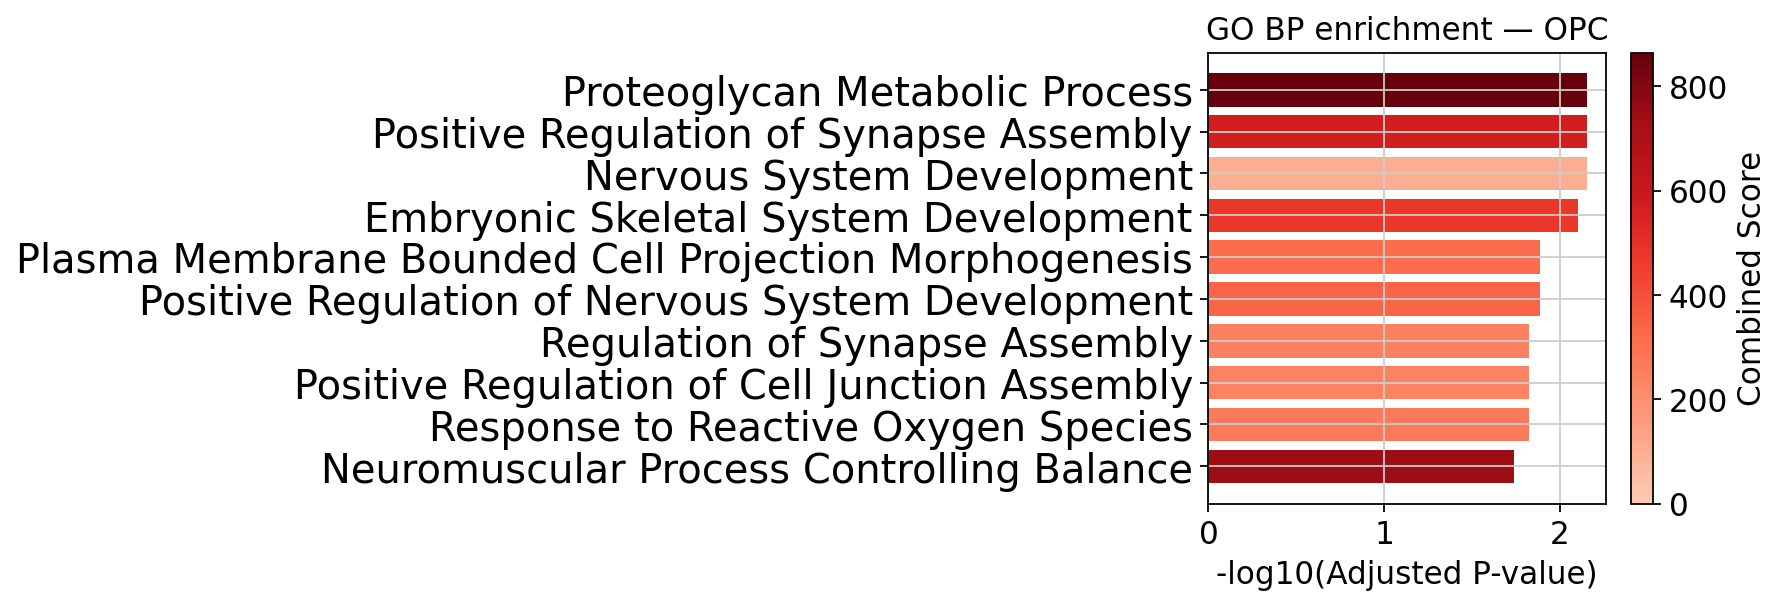

tODC


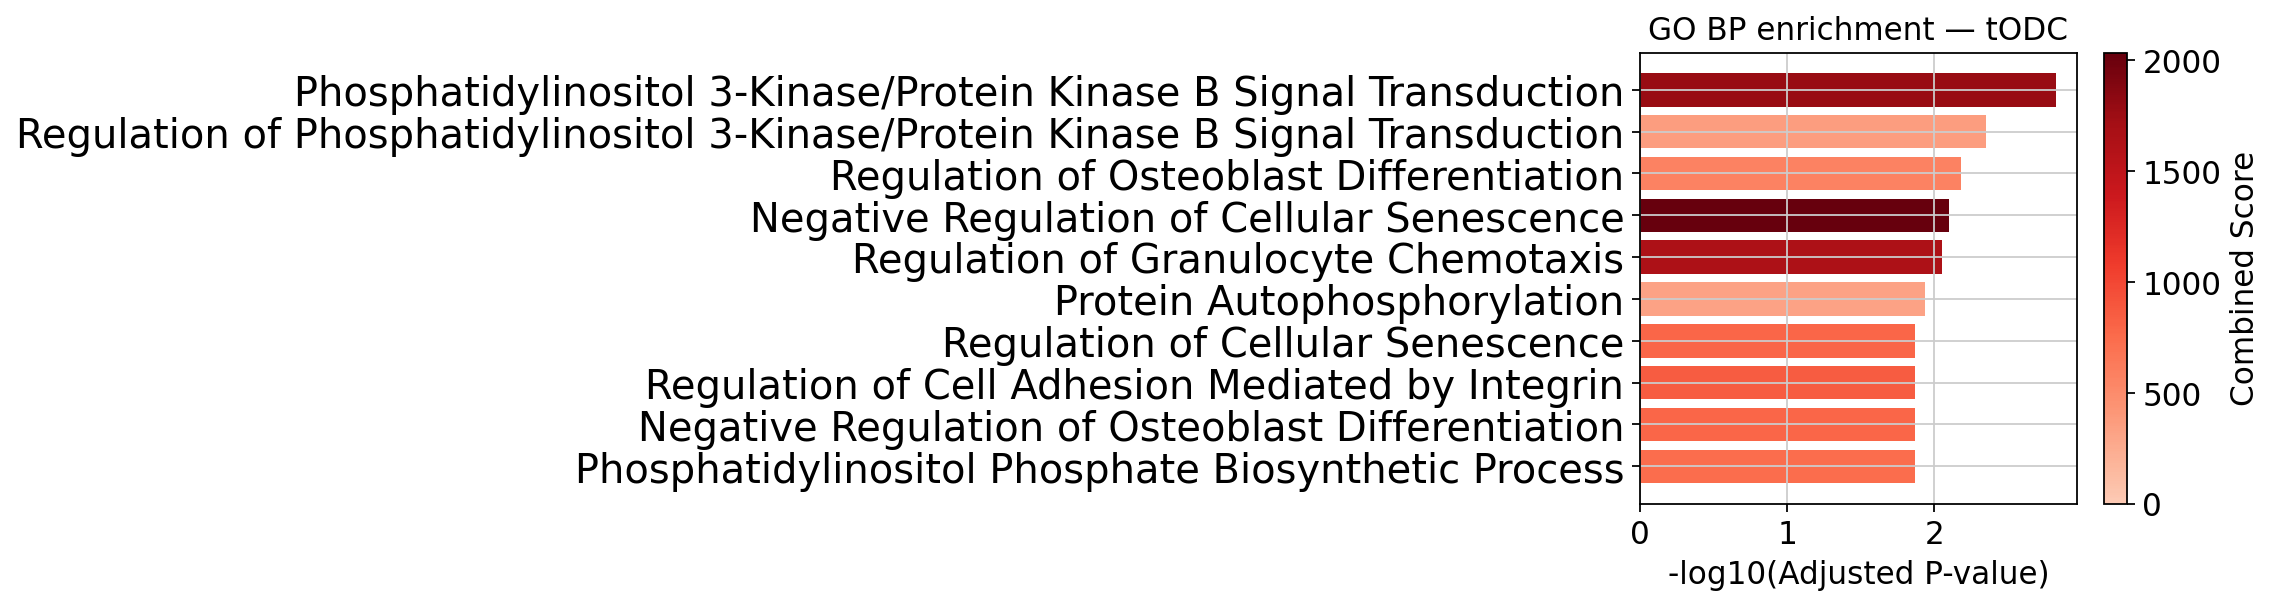

tOPC


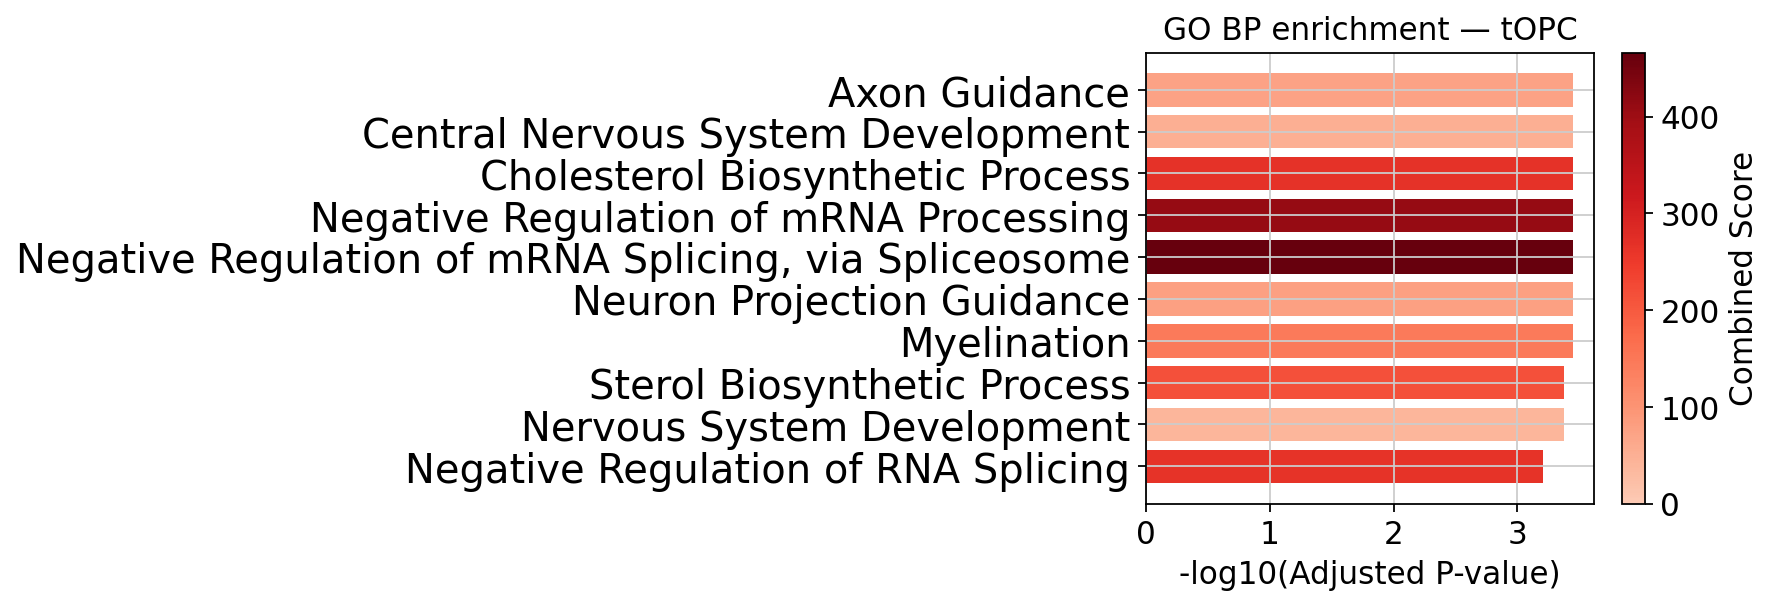

In [28]:
top_n=run_go_enrichment(celltype_genes)
plot_go_enrichment(top_n)